Chapter 01

# 条件概率

《概率统计》 | 鸢尾花书：数学不难

### 1. 随机试验与样本生成

* 该代码模拟的是一个**独立同分布（i.i.d.）离散随机试验**：
  $$
  X_1, X_2, \dots, X_n \sim \text{Uniform}{1,2,3,4,5,6}
  $$

其中：

* $n = 1000$
* 每个 $X_i$ 表示第 $i$ 次掷骰子的结果

满足：
$$
P(X_i = k) = \frac{1}{6}, \quad k = 1,2,3,4,5,6
$$

---

### 2. 事件定义与集合刻画

定义两个事件：

* 偶数事件：
  $$
  E = {2,4,6}
  $$

* 点数为6的事件：
  $$
  S = {6}
  $$

则有：
$$
S \subset E
$$

---

### 3. 条件概率的理论值

条件概率定义为：
$$
P(S \mid E) = \frac{P(S \cap E)}{P(E)}
$$

由于：
$$
S \cap E = S
$$

因此：
$$
P(S \mid E) = \frac{P(S)}{P(E)} = \frac{\frac{1}{6}}{\frac{3}{6}} = \frac{1}{3}
$$

---

### 4. 经验条件概率（频率估计）

代码通过样本路径估计条件概率：

* 偶数出现的次数：
  $$
  N_E = \sum_{i=1}^n \mathbf{1}_{{X_i \in E}}
  $$

* 同时为6的次数：
  $$
  N_{S \cap E} = \sum_{i=1}^n \mathbf{1}_{{X_i = 6}}
  $$

经验条件概率为：
$$
\hat{P}(S \mid E) = \frac{N_{S \cap E}}{N_E}
$$

这对应代码中的：

* `even_count`
* `six_given_even / even_count`

---

### 5. 条件概率的逐步收敛过程

进一步，代码计算“随时间演化的条件概率”：

对于每个时刻 $i$：

* 定义前缀样本：
  $$
  (X_1, \dots, X_i)
  $$

* 偶数子样本：
  $$
  E_i = {X_j \mid j \le i,, X_j \in E}
  $$

* 条件频率：
  $$
  \hat{P}*i(S \mid E) = \frac{\sum*{j=1}^i \mathbf{1}*{{X_j = 6}}}{\sum*{j=1}^i \mathbf{1}_{{X_j \in E}}}
  $$

这对应代码中的：

* `even_so_far`
* `six_in_even`

---

### 6. 大数定律的体现

根据**大数定律（Law of Large Numbers）**：

$$
\hat{P}_i(S \mid E) \xrightarrow[i \to \infty]{} P(S \mid E) = \frac{1}{3}
$$

即：

* 初期波动较大
* 随着样本增加，逐渐稳定在理论值附近

---

### 7. 边际概率的累积估计

代码还计算每个点数的累积概率：

对于 $k \in {1,\dots,6}$：
$$
\hat{P}*i(X = k) = \frac{1}{i} \sum*{j=1}^i \mathbf{1}_{{X_j = k}}
$$

这构成一个 $6$ 维向量：
$$
\hat{\mathbf{P}}_i = \left(\hat{P}_i(1), \dots, \hat{P}_i(6)\right)
$$

满足：
$$
\hat{P}_i(k) \xrightarrow[i \to \infty]{} \frac{1}{6}
$$

---

### 8. 数学结构总结

这段代码本质上实现了三个层次的概率结构：

1. **随机变量层**：
   $$
   X_i \sim \text{Uniform}{1,\dots,6}
   $$

2. **事件层（条件结构）**：
   $$
   S \subset E \subset \Omega
   $$

3. **频率逼近概率**：
   $$
   \hat{P}_i \to P
   $$

特别是：
$$
\hat{P}_i(S \mid E) \to \frac{1}{3}
$$

---

### 9. 本质一句话

这段代码用**随机模拟 + 频率统计**，在数值上验证了：
$$
P(6 \mid \text{even}) = \frac{1}{3}
$$

并展示了该条件概率如何在样本路径上逐步收敛到理论值。


## 初始化

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

## 数据

In [5]:
# 设置随机种子
# random.seed(42)

# 模拟参数
num_throws = 1000

# 存储每次抛掷的结果
throws = []
for i in range(num_throws):
    result = random.randint(1, 6)
    throws.append(result)

# 转换为numpy数组便于计算
throws = np.array(throws)
x_vals = np.arange(1, num_throws + 1)

# 计算条件概率
# 找出所有偶数位置
even_indices = np.where(throws % 2 == 0)[0]
even_count = len(even_indices)

# 找出所有6的位置
six_indices = np.where(throws == 6)[0]
# 找出既是偶数又是6的位置（其实就是6的位置，因为6是偶数）
six_given_even = len(np.intersect1d(even_indices, six_indices))

# 计算条件概率
if even_count > 0:
    conditional_prob = six_given_even / even_count
else:
    conditional_prob = 0

# 理论值
theoretical_prob = 1/3

# 计算累积概率
cumulative_probs = np.zeros((num_throws, 6))

for i in range(num_throws):
    for num in range(1, 7):
        # 计算到第i次为止，每个数字出现的累积概率
        cumulative_probs[i, num-1] = np.sum(throws[:i+1] == num) / (i+1)

# 颜色映射
# colors_map = {1: 'blue', 2: 'green', 3: 'red', 4: 'purple', 5: 'orange', 6: 'brown'}

colors_map = {
    1: '#FF0000',  # 红
    2: '#00AA00',  # 绿
    3: '#0000FF',  # 蓝
    4: '#FF9900',  # 橙
    5: '#9900FF',  # 紫
    6: '#00CCCC',  # 青
}
# colors = [colors_map[val] for val in throws]
# 为每次抛掷设置颜色（偶数用亮色，奇数用灰色）
colors = []
for result in throws:
    if result % 2 == 0:
        if result == 2:
            colors.append('#00AA00')
        elif result == 4:
            colors.append('#FF9900')
        else:  # 6
            colors.append('#00CCCC')
    else:
        colors.append('lightgray')

## 可视化

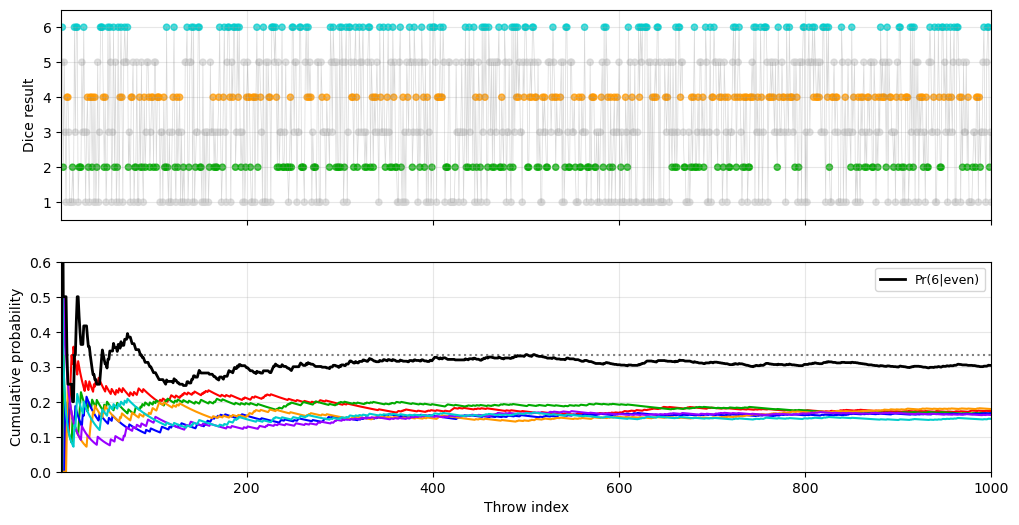

In [7]:
# 创建图形
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), 
                               height_ratios=[1, 1], 
                               sharex=True)

# 上图：抛掷结果散点图
ax1.plot(x_vals, throws, color='gray', linewidth=0.5, alpha=0.3)
ax1.scatter(x_vals, throws, c=colors, s=20, alpha=0.7)
ax1.set_ylabel('Dice result')
ax1.set_yticks([1, 2, 3, 4, 5, 6])
ax1.set_xlim(1, x_vals.max())
ax1.set_ylim(0.5, 6.5)
ax1.grid(True, alpha=0.3)
# ax1.set_title('抛色子结果分布 (金色为6, 亮绿色为2, 亮蓝色为4)')

# 在下图中添加条件概率的标注
even_props = []
for i in range(num_throws):
    even_so_far = throws[:i+1][throws[:i+1] % 2 == 0]
    if len(even_so_far) > 0:
        six_in_even = np.sum(even_so_far == 6) / len(even_so_far)
        even_props.append(six_in_even)
    else:
        even_props.append(0)

# 下图：累积概率曲线
for i in range(6):
    ax2.plot(x_vals, cumulative_probs[:, i], 
             color=colors_map[i+1], 
             linewidth=1.5)

# 添加条件概率曲线
ax2.plot(x_vals, even_props, color='black', linewidth=2, 
         linestyle='-', label='Pr(6|even)')

# 添加理论值参考线
# ax2.axhline(y=1/6, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(y=1/3, color='black', linestyle=':', alpha=0.5)

ax2.set_xlabel('Throw index')
ax2.set_ylabel('Cumulative probability')
ax2.set_xlim(1, x_vals.max())
ax2.set_ylim(0, 0.6)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', ncol=3, fontsize=9)

# plt.tight_layout()
# plt.show()


作者	**生姜DrGinger**  
脚本	**生姜DrGinger**  
视频	**崔崔CuiCui**  
开源资源	[**GitHub**](https://github.com/Visualize-ML)  
平台	[**油管**](https://www.youtube.com/@DrGinger_Jiang)		
		[**iris小课堂**](https://space.bilibili.com/3546865719052873)		
		[**生姜DrGinger**](https://space.bilibili.com/513194466)  